In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
print(PROJECT_ROOT)

/Users/florianb/Downloads/ai-customer-insights-engine


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.rag import document_processing

from config import config

In [3]:
import importlib

importlib.reload(config)
importlib.reload(document_processing)

<module 'src.rag.document_processing' from '/Users/florianb/Downloads/ai-customer-insights-engine/src/rag/document_processing.py'>

In [4]:
print(f"REVIEW_MIN_LENGTH = {config.REVIEW_MIN_LENGTH}")
print(f"REVIEW_MAX_LENGTH = {config.REVIEW_MAX_LENGTH}")
print(f"SEPARATORS = {config.SEPARATORS}")
print(f"CHUNK_SIZE = {config.CHUNK_SIZE}")
print(f"CHUNK_OVERLAP = {config.CHUNK_OVERLAP}")

REVIEW_MIN_LENGTH = None
REVIEW_MAX_LENGTH = None
SEPARATORS = ['. ', '! ', '? ', '.', '!', '?', ' ', '']
CHUNK_SIZE = 700
CHUNK_OVERLAP = 100


In [5]:
df_processed = pd.read_parquet(PROJECT_ROOT / "data/processed/processed_reviews_test_notebook.parquet")

In [6]:
df_processed.head()

,publication_date,rating,title,review,experience_date,bank,review_id,year,month,year_month
0,2025-03-07 14:48:17+01:00,5,Banque pas chère,Banque pas chère,2025-03-07,boursobank,0,2025,3,2025-03
1,2025-03-07 14:45:35+01:00,5,Modif plafond retrait,"Gestion aisée de mon compte. Pas de frais, auc...",2025-03-07,boursobank,1,2025,3,2025-03
2,2025-03-07 14:35:24+01:00,5,Facilité,Rajouter un bénéficiaire et tout s'est bien dé...,2025-03-07,boursobank,2,2025,3,2025-03
3,2025-03-07 14:20:03+01:00,4,Trop d'étape de sécurité,J'ai mis 4 étoiles parce que je trouve qu'il a...,2025-03-01,boursobank,3,2025,3,2025-03
4,2025-03-07 13:28:32+01:00,4,Je recommande cette carte pour les…,Je recommande cette carte pour les voyageurs e...,2025-03-06,boursobank,4,2025,3,2025-03


In [7]:
df_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 48389 entries, 0 to 48388
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype                       
---  ------            --------------  -----                       
 0   publication_date  48389 non-null  datetime64[us, Europe/Paris]
 1   rating            48389 non-null  int64                       
 2   title             48389 non-null  str                         
 3   review            48389 non-null  str                         
 4   experience_date   48389 non-null  datetime64[us]              
 5   bank              48389 non-null  str                         
 6   review_id         48389 non-null  int64                       
 7   year              48389 non-null  int32                       
 8   month             48389 non-null  int32                       
 9   year_month        48389 non-null  str                         
dtypes: datetime64[us, Europe/Paris](1), datetime64[us](1), int32(2), int64(2), str(4)

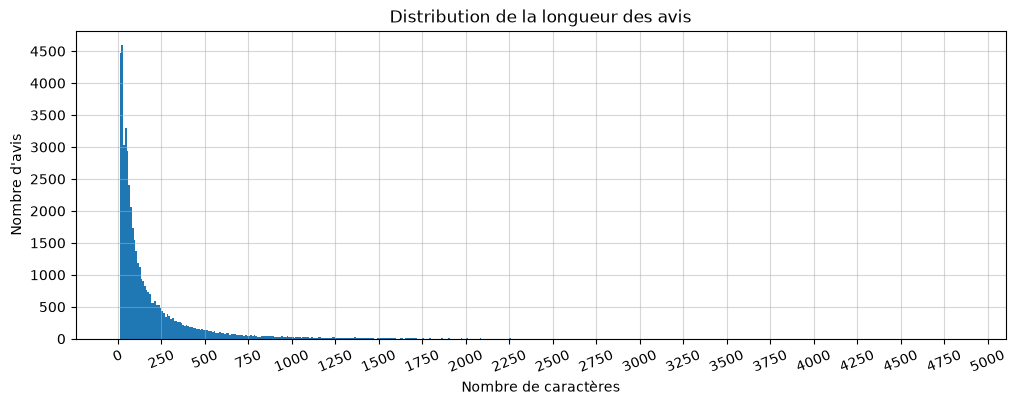

In [8]:
# Distribution de la longueur des avis
review_lengths = df_processed["review"].str.len()

bins = np.arange(0, review_lengths.max() + 10, 10)


plt.figure(figsize=(12, 4))

plt.hist(review_lengths, bins=bins)

plt.xticks(np.arange(0, plt.xlim()[1], 250), rotation=45/2)
plt.yticks(np.arange(0, plt.ylim()[1], 500))

plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'avis")

plt.title("Distribution de la longueur des avis")

plt.grid(alpha=0.5)

plt.show()

In [9]:
# Statistiques sur la longueur des avis
review_lengths.describe(percentiles=[.01, .05, .95, .99]).round(2)

count    48389.00
mean       190.02
std        291.04
min         10.00
1%          12.00
5%          16.00
95%        702.00
99%       1412.12
max       4855.00
Name: review, dtype: float64

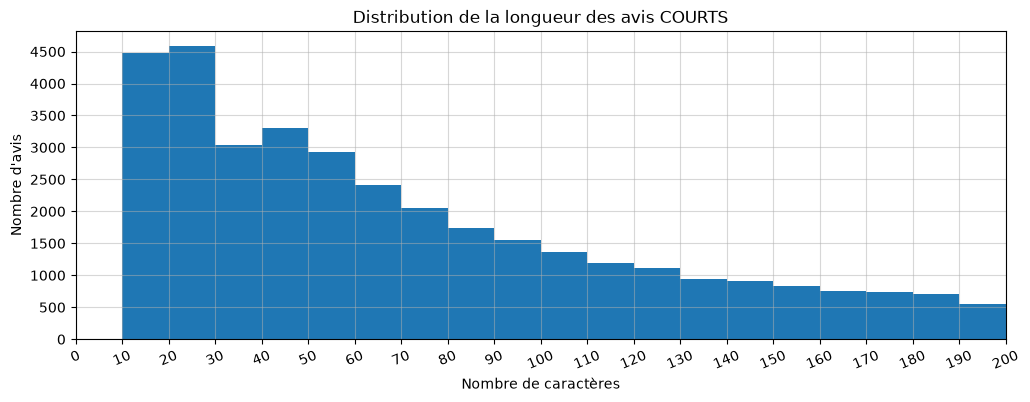

In [10]:
# Distribution de la longueur des avis COURTS
review_lengths = df_processed["review"].str.len()

max_characters = 200
bins = np.arange(0, max_characters + 10, 10)


plt.figure(figsize=(12, 4))

plt.hist(review_lengths[review_lengths < max_characters], bins=bins)

plt.xlim(0, max_characters)

plt.xticks(bins, rotation=45/2)
plt.yticks(np.arange(0, plt.ylim()[1], 500))

plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'avis")

plt.title("Distribution de la longueur des avis COURTS")

plt.grid(alpha=0.5)

plt.show()

In [11]:
# Nombre d'avis de moins de 12 caractères
(df_processed["review"].str.len() <= 12).sum()

722

In [12]:
# Avis de moins de 12 caractères
df_processed[df_processed["review"].str.len() <= 12][["review_id", "title", "review"]].head(60)

,review_id,title,review
26,30,Très simple,Très simple
61,75,Merci merci,Merci merci
189,216,Bien,Efficacité
243,279,Super banque,Super banque
256,296,Très rapide,Très rapide
269,310,Excellente,Excellente
287,329,Excellent,Bonne banque
298,341,Virement,Super rapide
299,342,Rien à améliorer,Rien à dire.
300,343,Très rapide,Très rapide


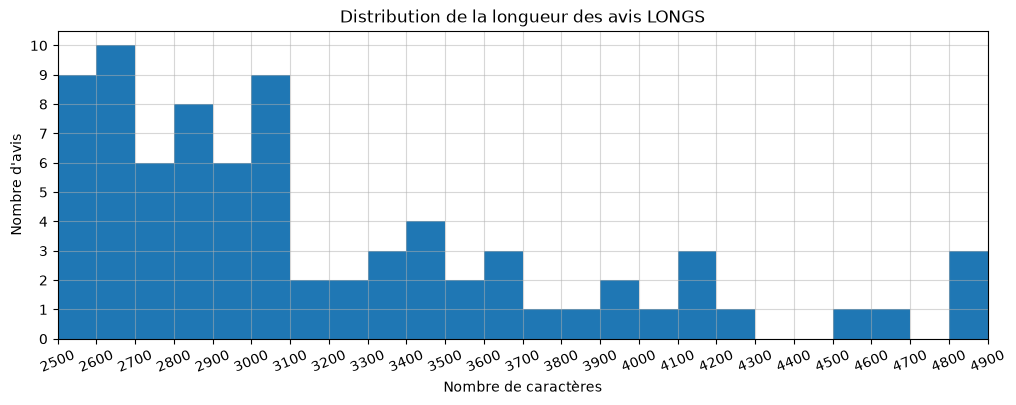

In [13]:
# Distribution de la longueur des avis LONGS
review_lengths = df_processed["review"].str.len()

min_characters = 2500
max_characters = review_lengths.max()
bins = np.arange(min_characters, max_characters + 100, 100)


plt.figure(figsize=(12, 4))

plt.hist(review_lengths[review_lengths > min_characters], bins=bins)

plt.xlim(min_characters, max_characters)

plt.xticks(bins, rotation=45/2)
plt.yticks(np.arange(0, plt.ylim()[1], 1))

plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre d'avis")

plt.title("Distribution de la longueur des avis LONGS")

plt.grid(alpha=0.5)

plt.show()

In [14]:
# Nombre d'avis de plus de 1412 caractères
(df_processed["review"].str.len() >= 1412).sum()

486

In [15]:
# Avis de plus de 1412 caractères
pd.set_option("display.max_colwidth", None)
df_processed[df_processed["review"].str.len() >= 1412][["review_id", "title", "review"]].head()

,review_id,title,review
41,51,Très mitigé.,"Je suis plus que mitigée sur cette banque et ses offres. Un certain nombre de choses sont très appréciables : la possibilité de faire des virements en devises, les virements instantanés gratuits et avec des limites assez élevées, les virements standards illimités. Néanmoins, ce sont des fonctionnalités que l'on utilise rarement, et cela ne suffit pas à compenser les problèmes que personnellement je rencontre au quotidien :1) Une carte Visa Welcome à la limite de l'inutilisable : le plafond de paiement est ridicule (1000€ par 30 jours glissants.... qui peut vivre avec une telle somme aujourd'hui ? ) et il semble impossible de l'augmenter, j'ai systématiquement un message d'erreur me disant ""votre situation ne permet pas d'augmenter votre plafond"" sans autre explication. Que faut-il de plus qu'un compte créditeur sans incident ? Selon les CGV, je ne suis pas censée rencontrer ce problème. C'est particulièrement handicapant car cela m'oblige à jongler avec plusieurs comptes bancaires. 2) Toutes les cartes sont à autorisation systématique. C'est un enfer : si vous budgétez serré, oubliez de mettre 20€ de carburant avec ce qu'il vous reste sur votre compte, ce sera refusé. Et si jamais l'autorisation échoue, votre carte est débitée quand même, et il faut plus de 8 jours pour retrouver vos fonds. Dommage pour vous si c'était tout ce qu'il vous restait. 3) Le service client n'est pas joignable autrement qu'avec un rappel téléphonique. Personnellement, cela ne me convient pas, et encore moisn puisque la seule et unique fois où j'ai eu quelqu'un, il a été totalement incompétent à résoudre mon problème, m'a débité un laïus préétabli visant à noyer le poisson, et au final, mon problème n'a pas été résolu. Rajoutez à cela les arrivées de virement fantaisistes, les prélèvements de frais astronomiques pour quelque fois quelques minutes de valeur, les changements de conditions sans préavis, et les conversion devises/euros souvent douteuses, et cela devient assez problématique à utiliser."
175,200,"Un cauchemar de ""Banque"".","Un cauchemar de ""Banque"". A la suite d'une dépense frauduleuse début 2024, au Chili apparemment , car n'ayant pas fait l'objet d'une quelconque authentification par Bourso Bank j'ai fait appel à un avocat pour assigner cette "" banque au tribunal afin d'attester ma bonne foi. Frais d'avocats : 1800 € . A la suite de quoi , une transaction a été proposée par l'avocat de la ""banque"" que j'ai acceptée à contre coeur car elle n'incluait pas les frais de justice. Pour des ""raisons de convenance"" , Bourso Bank a décidé de clôturer le compte concerné par la fraude. Ce qui me va parfaitement n'ayant plus aucune confiance dans cet établissement virtuel . MAIS c'est insuffisant! Je souhaite sortir tous , je dis bien tous mes avoirs ( j'ai 3 comptes chez eux) afin de les domicilier dans une vraie banque. Tâche impossible pour 3 raisons :1/ IQera la société de contentieux de ladite ""banque"" n'a jamais été avisée de l'accord passé !!!!! 2/ Mes numéros de téléphone pour appeler le service client sont systématiquement bloqués . Sympa. 3/ Il en est de même pour mon accès client sur le site de Bourso Bank , il me l'interdisent. Cool. Non seulement ils se sont assis sur leur obligation de régler, rubis sur l'ongle , les dépenses frauduleuses qui ont fait l'objet d'un signalement au Commissariat de police , tel le sparadrap du capitaine Haddock , il m'est impossible de me dégager de cette "" banque"" pour y mettre tous mes dépôts dans un établissement ayant pignon sur rue. Notre Président n'était- il pas lui-même banquier et l'a t'on informé du non respect de leurs obligations de certaines banques?"
338,386,Client depuis 2008,"Client depuis 2008, avec un compte joins avec mon épouse, livrets, Ass vie. La banque a bloqué l’accès au compte de mon épouse suite à un dysfonctionnement de leurs systèmes d’authentifications qui envoie un SMS sur un téléphone fixe. Et ce serait au client d'en

### Validation de `filter_reviews()`

In [16]:
# Nombre d'avis de moins de 12 caractères et de plus de 3200 caractères
print(len(df_processed[df_processed["review"].str.len()<12]))
print(len(df_processed[df_processed["review"].str.len()>3200]))

460
28


In [17]:
filtered_df = document_processing.filter_reviews(
    df=df_processed,
    review_min_length=12,
    review_max_length=3200,
)

In [18]:
# Nombre d'avis de moins de 12 caractères et de plus de 3200 caractères
print(len(filtered_df[filtered_df["review"].str.len()<12]))
print(len(filtered_df[filtered_df["review"].str.len()>3200]))

0
0


### Validation de `create_documents()`

In [19]:
df_processed.head()

,publication_date,rating,title,review,experience_date,bank,review_id,year,month,year_month
0,2025-03-07 14:48:17+01:00,5,Banque pas chère,Banque pas chère,2025-03-07,boursobank,0,2025,3,2025-03
1,2025-03-07 14:45:35+01:00,5,Modif plafond retrait,"Gestion aisée de mon compte. Pas de frais, aucun problème.",2025-03-07,boursobank,1,2025,3,2025-03
2,2025-03-07 14:35:24+01:00,5,Facilité,Rajouter un bénéficiaire et tout s'est bien déroulé.,2025-03-07,boursobank,2,2025,3,2025-03
3,2025-03-07 14:20:03+01:00,4,Trop d'étape de sécurité,J'ai mis 4 étoiles parce que je trouve qu'il a beaucoup etapes de sécurité C'est compréhensif mais ça mis trop de temps et trop d'étape pour faire un truc simple C'était juste mes débuts peut-être après je changerai d'avis 😉,2025-03-01,boursobank,3,2025,3,2025-03
4,2025-03-07 13:28:32+01:00,4,Je recommande cette carte pour les…,Je recommande cette carte pour les voyageurs et pour les commandes sur internet,2025-03-06,boursobank,4,2025,3,2025-03


In [20]:
# Nombre d'avis
len(df_processed)

48389

In [21]:
documents = document_processing.create_documents(
    df=df_processed,
    dataset_name="processed_reviews_test_notebook",
)

In [22]:
# Nombre d'avis sous forme de documents LangChain
len(documents)

48389

In [23]:
documents[:5]

[Document(metadata={'title': 'Banque pas chère', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:48:17+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 0, 'dataset': 'processed_reviews_test_notebook'}, page_content='Banque pas chère'),
 Document(metadata={'title': 'Modif plafond retrait', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:45:35+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 1, 'dataset': 'processed_reviews_test_notebook'}, page_content='Gestion aisée de mon compte. Pas de frais, aucun problème.'),
 Document(metadata={'title': 'Facilité', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:35:24+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 2, 'dataset': 'processed_reviews_test_notebook'}, page_content="Rajouter un bénéficiaire et tout s'est bien déroulé."),
 Document(metadata={'title': "Trop d'étape de sécurité", 'bank': 'boursobank', 'rating': 4, 'publication_date

In [24]:
for doc in documents[:5]:
    print("Avis client :", doc.page_content)
    print("Metadata :", doc.metadata, "\n")

Avis client : Banque pas chère
Metadata : {'title': 'Banque pas chère', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:48:17+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 0, 'dataset': 'processed_reviews_test_notebook'} 

Avis client : Gestion aisée de mon compte. Pas de frais, aucun problème.
Metadata : {'title': 'Modif plafond retrait', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:45:35+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 1, 'dataset': 'processed_reviews_test_notebook'} 

Avis client : Rajouter un bénéficiaire et tout s'est bien déroulé.
Metadata : {'title': 'Facilité', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:35:24+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 2, 'dataset': 'processed_reviews_test_notebook'} 

Avis client : J'ai mis 4 étoiles parce que je trouve qu'il a beaucoup etapes de sécurité C'est compréhensif mais ça mis trop de temps et tr

### Validation de `chunk_documents()`

In [25]:
chunked_documents = document_processing.chunk_documents(
    documents=documents,
    separators=[". ", "! ", "? ", ".", "!", "?", " ", ""],
    chunk_size=700,
    chunk_overlap=100,
)

In [26]:
# Nombre d'avis sous forme de documents LangChain après chunking
len(chunked_documents)

52013

In [27]:
chunked_documents[:5]

[Document(metadata={'title': 'Banque pas chère', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:48:17+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 0, 'dataset': 'processed_reviews_test_notebook'}, page_content='Banque pas chère'),
 Document(metadata={'title': 'Modif plafond retrait', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:45:35+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 1, 'dataset': 'processed_reviews_test_notebook'}, page_content='Gestion aisée de mon compte. Pas de frais, aucun problème.'),
 Document(metadata={'title': 'Facilité', 'bank': 'boursobank', 'rating': 5, 'publication_date': '2025-03-07T14:35:24+01:00', 'experience_date': '2025-03-07T00:00:00', 'review_id': 2, 'dataset': 'processed_reviews_test_notebook'}, page_content="Rajouter un bénéficiaire et tout s'est bien déroulé."),
 Document(metadata={'title': "Trop d'étape de sécurité", 'bank': 'boursobank', 'rating': 4, 'publication_date

In [28]:
# Nombre de chunks par avis
from collections import Counter

chunks_per_review = Counter(
    chunk.metadata["review_id"] for chunk in chunked_documents
)

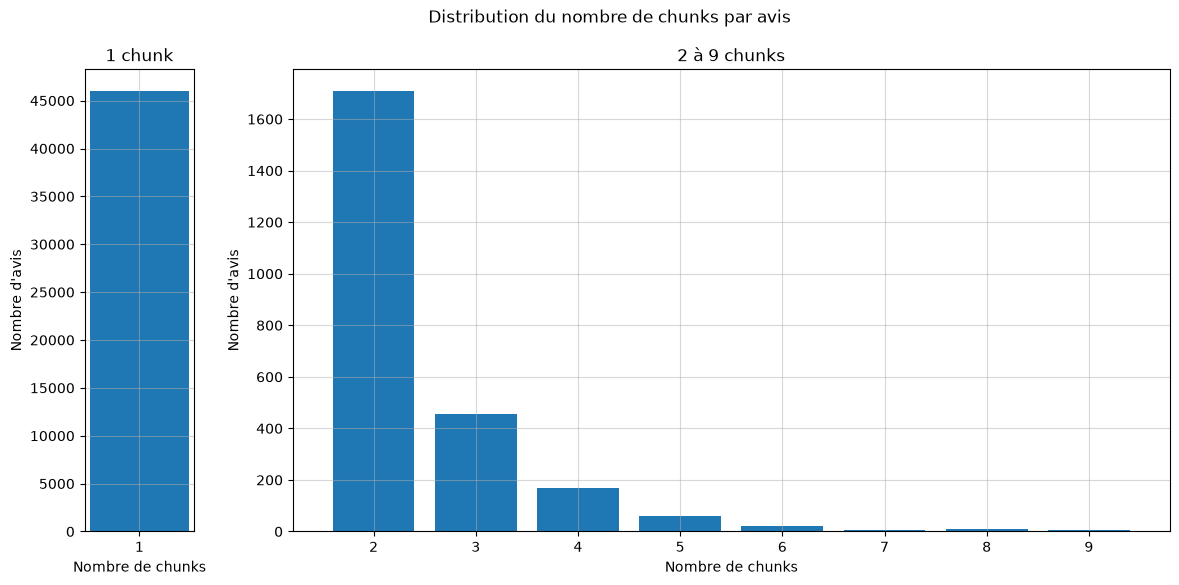

In [30]:
# Distribution du nombre de chunks par avis
counts = Counter(chunks_per_review.values())


fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    gridspec_kw={"width_ratios": [1, 8]}
)


# 1 chunk
x1 = [1]
y1 = [counts.get(x, 0) for x in x1]

axes[0].bar(x1, y1)

axes[0].set_xticks(x1)
axes[0].set_yticks(np.arange(0, y1[0], 5000))

axes[0].set_xlabel("Nombre de chunks")
axes[0].set_ylabel("Nombre d'avis")

axes[0].set_title("1 chunk")

axes[0].grid(alpha=0.5)


# 2 à 9 chunks
x2 = np.arange(2, 10)
y2 = [counts.get(x, 0) for x in x2]

axes[1].bar(x2, y2)

axes[1].set_xticks(x2)

axes[1].set_xlabel("Nombre de chunks")
axes[1].set_ylabel("Nombre d'avis")

axes[1].set_title("2 à 9 chunks")

axes[1].grid(alpha=0.5)


plt.suptitle("Distribution du nombre de chunks par avis")

#plt.tight_layout()
plt.show()

In [31]:
# Avis avec 1 unique chunk et la longueur de ces chunks
single_chunk_reviews = [
    {
        "review_id": chunk.metadata["review_id"],
        "chunk_length": len(chunk.page_content)
    }
    for chunk in chunked_documents
    if chunks_per_review[chunk.metadata["review_id"]] == 1
]

In [33]:
# Nombre d'avis avec 1 unique chunk
len(single_chunk_reviews)

45954

In [34]:
chunk_lengths = pd.Series(
    [x["chunk_length"] for x in single_chunk_reviews]
)

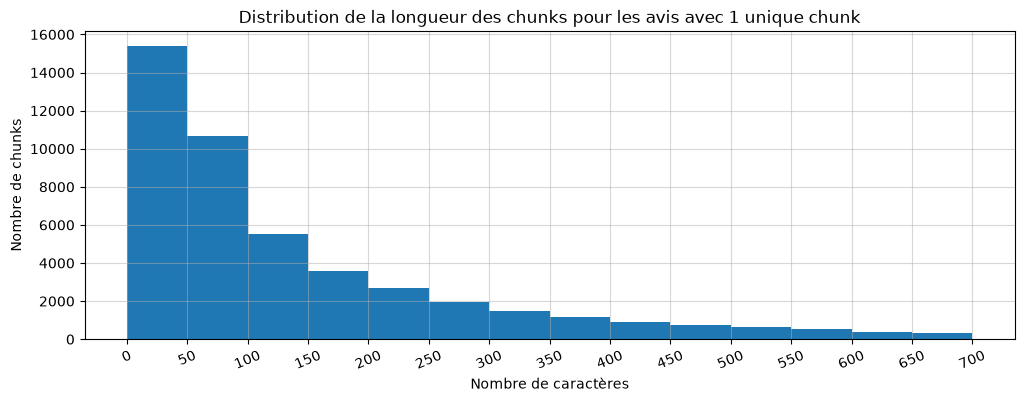

In [ ]:
# Distribution de la longueur des chunks pour les avis avec 1 unique chunk
bins = np.arange(0, chunk_lengths.max() + 50, 50)


plt.figure(figsize=(12, 4))

plt.hist(chunk_lengths, bins=bins)

plt.xticks(bins, rotation=45/2)

plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de chunks")

plt.title("Distribution de la longueur des chunks pour les avis avec 1 unique chunk")

plt.grid(alpha=0.5)

plt.show()

In [36]:
# Statistiques sur la longueur des chunks pour les avis avec 1 unique chunk
chunk_lengths.describe().round(2)

count    45954.00
mean       138.32
std        144.42
min         10.00
25%         37.00
50%         80.00
75%        187.00
max        699.00
dtype: float64

In [37]:
# Avis composés de plusieurs chunks
multi_chunk_reviews = {
    review_id
    for review_id, count in chunks_per_review.items()
    if count > 1
}

In [39]:
# 1ers chunks des avis composés de plusieurs chunks et la longueur de ces chunks
first_chunks_multi_chunk_reviews = []
seen_reviews = set()

for chunk in chunked_documents:
    review_id = chunk.metadata["review_id"]

    if review_id in multi_chunk_reviews and review_id not in seen_reviews:
        first_chunks_multi_chunk_reviews.append({
            "review_id": review_id,
            "chunk_length": len(chunk.page_content)
        })
        seen_reviews.add(review_id)

In [41]:
first_chunks_df = pd.DataFrame(first_chunks_multi_chunk_reviews)

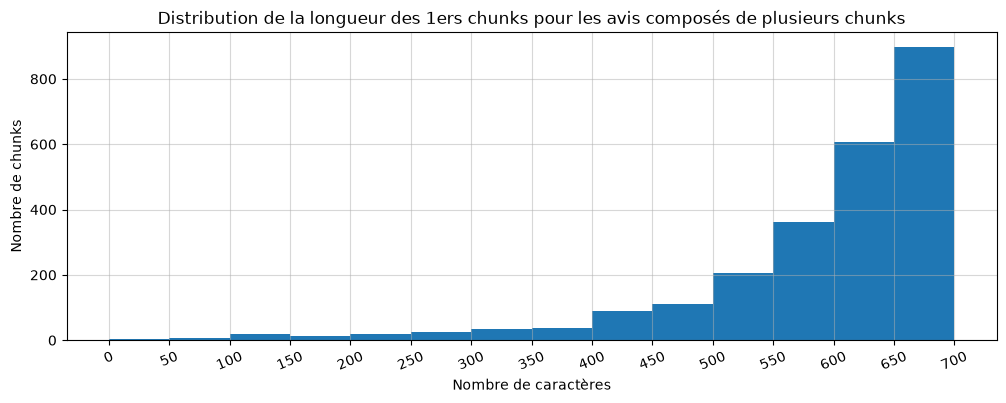

In [ ]:
# Distribution de la longueur des 1ers chunks pour les avis composés de plusieurs chunks
bins = np.arange(0, first_chunks_df["chunk_length"].max() + 50, 50)


plt.figure(figsize=(12, 4))

plt.hist(first_chunks_df["chunk_length"], bins=bins)

plt.xticks(bins, rotation=45/2)

plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de chunks")

plt.title("Distribution de la longueur des 1ers chunks pour les avis composés de plusieurs chunks")

plt.grid(alpha=0.5)

plt.show()

In [43]:
# Statistiques sur la longueur des 1ers chunks pour les avis composés de plusieurs chunks
first_chunks_df["chunk_length"].describe().round(2)

count    2435.00
mean      591.22
std       113.37
min         8.00
25%       556.50
50%       626.00
75%       667.00
max       699.00
Name: chunk_length, dtype: float64

In [44]:
# IDs des avis dont les 1ers chunks sont inférieurs à 50 caractères
short_review_ids = first_chunks_df[first_chunks_df["chunk_length"]<50]["review_id"]

In [46]:
# Chunks des avis dont les 1ers chunks sont inférieurs à 50 caractères
short_first_chunks = [
    chunk
    for chunk in chunked_documents
    if chunk.metadata["review_id"] in short_review_ids.values
]

In [47]:
short_first_chunks

[Document(metadata={'title': 'Le service client est une catastrophe', 'bank': 'boursobank', 'rating': 1, 'publication_date': '2023-01-11T13:23:10+01:00', 'experience_date': '2022-12-05T00:00:00', 'review_id': 6418, 'dataset': 'processed_reviews_test_notebook'}, page_content='Le service client est une catastrophe.'),
 Document(metadata={'title': 'Le service client est une catastrophe', 'bank': 'boursobank', 'rating': 1, 'publication_date': '2023-01-11T13:23:10+01:00', 'experience_date': '2022-12-05T00:00:00', 'review_id': 6418, 'dataset': 'processed_reviews_test_notebook'}, page_content='Suite à une demande d\'opération qui sort un peu du cadre des opérations standards accessibles en ligne, je suis confronté à une situation surréelle :- les emails du service client ne partent pas depuis des semaines mais apparemment "c\'est un problème qui perdure nous ne savons pas pour combien de temps"- le service client, certes sympathique, n\'est en mesure d\'apporter aucune solution lors d\'un app

In [48]:
# Avis dont les 1ers chunks sont inférieurs à 50 caractères
df_processed[df_processed["review_id"].isin(short_review_ids)][["review_id", "title", "review"]].head()

,review_id,title,review
5553,6418,Le service client est une catastrophe,"Le service client est une catastrophe. Suite à une demande d'opération qui sort un peu du cadre des opérations standards accessibles en ligne, je suis confronté à une situation surréelle :- les emails du service client ne partent pas depuis des semaines mais apparemment ""c'est un problème qui perdure nous ne savons pas pour combien de temps""- le service client, certes sympathique, n'est en mesure d'apporter aucune solution lors d'un appel, ni d'indiquer des délais de traitement- impossible de parler à qui que ce soit qui aurait les informations- impossible d'avoir un suivi avec un membre du service client car on passe sans cesse par le standard et il n'est pas possible d'établir une correspondance email qui serait 1000 fois plus pratiqueA éviter car lorsque vous avez une galère, celle-ci prend des proportions aberrantes."
23220,26775,Des incapable !!!,"Bonjour a tous Je vous explique ma situation .. Depuis le 20 Decembre boursorama Banque a decider, sans raisons, de restreindre mon plafond et ducoup de me bloquer mon argent Suite a cela je les ai contacter par e-mail vue que pas téléphone impossible de les avoir J'ai reussi a avoir une réponse "" ce qui est assez rare chez eux ""- Dans le premier retour d'email on me dit que suite a 1 voir plusieurs incident sur mon compte ils ont du me bloquer mon argent - Ducoup je ne comprend pas trop et leur demande de quel incident il sagit ? - apres quelques jours sans réponses, je reçois un email de leur part disant qu'après vérification ils se sont aperçu qu'il ny a eu aucun incident sur mon compte, il s'exuse même pour la gêne occasioner ect ... malgres cela je n'ai toujours pas de retour a la normal sur mon compte Je ne peu toujours pas modifier mon plafond retrai et CB- alors pour te bloquer ton compte, te prendre ton argent ils sont fort mais parcontre pour débloquer tout leur merdier ils font durer !! A cause d'eux je ne peux pas payer mon loyer, mes prélèvements sont tous annuler les 1 apres les autresJe n'ai malheureusement pas pu offrir de cadeaux a mon fils cette année Et depuis ils font la sourde oreilleAuriez-vous s'il vous plaît une solution a on problème ? Je voulais envoyer un courrier au directeur mais je ne trouve aucune adresseMerci de votre aide Prenez tous bien soin de vousAurélie"
23879,27442,Boursorama,"https:// bour. so /AJtjmapqMD Je suis une étudiante et ça me dérangeait pas d'avoir un peu plus d'argent , c'est une amie qui m'a parrainée au début jy croyais pas même mon frère voulait pas que je le fasse pck il pensait que c'est une arnaque mais j'ai tout bien lu , j'ai regardé les avis etc et je me suis décidé à créé mon compte , une fois que je lai créé mon amie à eu c'est 110 euros et puis quand moi j'ai parrainé ma mère et ma cousine j'ai eu aussi 220 euro , si vous hésitez à créé ou pas un compte je vous conseille de le faire pck vs ne perdez rien mais au contraire vs gagnerez de l'argent /! \ petite astuce ne choisissez pas l'assurance et la carte bancaire si vous ne voulez pas payer des frais mensuel , comme ça paierez 0euro et si vous voulez retirer largent vs pouvez le transferer a votre comptz bancaire principal (ca , caisse depargne et.. )Je profite pr mettre mon lien de parrainage hehe. https:// bour. so /AJtjmapqMD"
35389,39894,A fuir!,"A fuir!! Que des soucis depuis l ouverture de mon compte , ils n ont pas pris en compte le code de bienvenue que j ai validé a l ouverture, (j ai du appeler 3 fois pour avoir mon identifiant deja la j aurais du fuir) ensuite ils bloquent mon accès au compte sur internet et ma carte bancaire sans me prévenir j ai appelé plusieurs fois ils ne savent pas pourquoi mon compte est bloqué alors ils me disent qui faut patienter plusieurs jours que c est en cours de traitement je leur ai dis inutile je cloture mon compte je ne vais pas rester a une banque qui ne communique pas qui vous bloque du jour au lendemain sans explication je n ai plus confiance,

In [ ]:
# SEPARATORS = [". ", "! ", "? ", ".", "!", "?", " ", ""]
# Dans les avis précédents, il y a une absence de ponctuation (point, point d'exclamation, point d'interrogation) pendant une longue partie du texte au début de l'avis.
# Cela explique que les 1ers chunks de ces avis soient très courts (moins de 50 caractères), et que le chunking puissent se faire sur des phrases incomplètes.

In [49]:
# Avis composés de 3 chunks ou plus
reviews_3plus = {
    review_id
    for review_id, count in chunks_per_review.items()
    if count >= 3
}

In [51]:
# 2e chunks des avis composés de 3 chunks ou plus
second_chunks_3plus = []
chunk_counts_seen = {}

for chunk in chunked_documents:
    review_id = chunk.metadata["review_id"]

    chunk_counts_seen[review_id] = chunk_counts_seen.get(review_id, 0) + 1

    if review_id in reviews_3plus and chunk_counts_seen[review_id] == 2:
        second_chunks_3plus.append(chunk)

In [52]:
second_chunks_lengths = pd.Series(
    [len(chunk.page_content) for chunk in second_chunks_3plus]
)

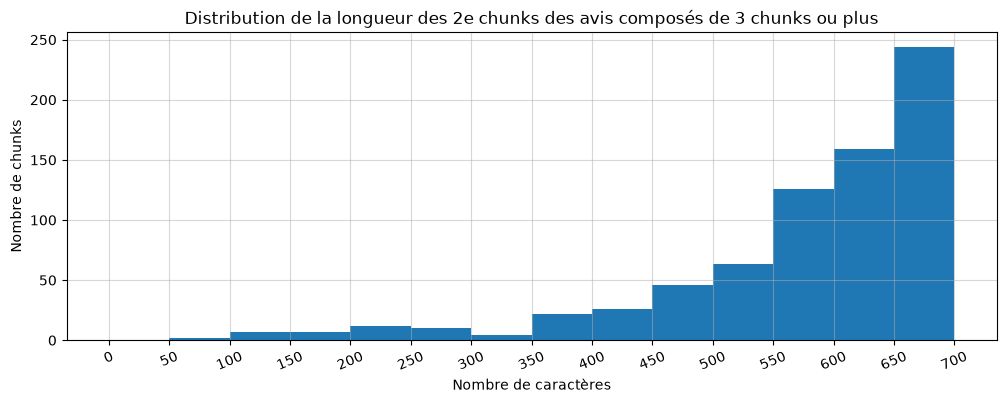

In [59]:
# Distribution de la longueur des 2e chunks des avis composés de 3 chunks ou plus
bins = np.arange(0, second_chunks_lengths.max() + 50, 50)


plt.figure(figsize=(12, 4))

plt.hist(second_chunks_lengths, bins=bins)

plt.xticks(bins, rotation=45/2)

plt.xlabel("Nombre de caractères")
plt.ylabel("Nombre de chunks")

plt.title("Distribution de la longueur des 2e chunks des avis composés de 3 chunks ou plus")

plt.grid(alpha=0.5)

plt.show()

### Validation du pipeline `prepare_chunked_documents()` via le notebook

In [60]:
chunked_documents_notebook = document_processing.prepare_chunked_documents(
    input_path=PROJECT_ROOT / "data/processed/processed_reviews_test_notebook.parquet"
)

In [61]:
len(chunked_documents_notebook)

52013

In [62]:
chunked_documents_notebook == chunked_documents

True